In [26]:
# ============================================
# CELL 1 — SETUP
# ============================================

import os
import torch

print("============================================")
print("CROWD INCIDENT DETECTION")
print("============================================")

print("PyTorch version:", torch.__version__)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU: CPU")


# ============================================
# DATASET PATH
# ============================================

DATASET_ROOT = "/kaggle/input/datasets/odins0n/ucf-crime-dataset"

TRAIN_DIR = os.path.join(
    DATASET_ROOT,
    "Train"
)

TEST_DIR = os.path.join(
    DATASET_ROOT,
    "Test"
)

print("\nDataset:", DATASET_ROOT)
print("Train exists:", os.path.exists(TRAIN_DIR))
print("Test exists :", os.path.exists(TEST_DIR))

CROWD INCIDENT DETECTION
PyTorch version: 2.10.0+cu128
Device: cuda
GPU: Tesla T4

Dataset: /kaggle/input/datasets/odins0n/ucf-crime-dataset
Train exists: True
Test exists : True


In [27]:
# ============================================
# Cell 2 DATASET CONFIGURATION
# ============================================

import os

DATASET_ROOT = "/kaggle/input/datasets/odins0n/ucf-crime-dataset"

TRAIN_DIR = os.path.join(DATASET_ROOT, "Train")
TEST_DIR = os.path.join(DATASET_ROOT, "Test")

print("============================================")
print("CROWD INCIDENT DETECTION")
print("============================================")

print("Dataset:", DATASET_ROOT)
print("Train exists:", os.path.exists(TRAIN_DIR))
print("Test exists :", os.path.exists(TEST_DIR))

if os.path.exists(TRAIN_DIR):
    print("\nTrain folders:")
    print(os.listdir(TRAIN_DIR))

if os.path.exists(TEST_DIR):
    print("\nTest folders:")
    print(os.listdir(TEST_DIR))

CROWD INCIDENT DETECTION
Dataset: /kaggle/input/datasets/odins0n/ucf-crime-dataset
Train exists: True
Test exists : True

Train folders:
['RoadAccidents', 'Assault', 'Vandalism', 'Arrest', 'Shooting', 'NormalVideos', 'Arson', 'Explosion', 'Shoplifting', 'Robbery', 'Stealing', 'Burglary', 'Abuse', 'Fighting']

Test folders:
['RoadAccidents', 'Assault', 'Vandalism', 'Arrest', 'Shooting', 'NormalVideos', 'Arson', 'Explosion', 'Shoplifting', 'Robbery', 'Stealing', 'Burglary', 'Abuse', 'Fighting']


In [28]:
# ============================================
# BUILD BINARY DATASET
# Normal = 0
# Abnormal = 1
# ============================================

import os
import random

SEED = 42
TRAIN_PER_CLASS = 1000
TEST_PER_CLASS = 300

NORMAL_CLASS = "NormalVideos"

ABNORMAL_CLASSES = [
    "Abuse",
    "Arrest",
    "Arson",
    "Assault",
    "Burglary",
    "Explosion",
    "Fighting",
    "RoadAccidents",
    "Robbery",
    "Shooting",
    "Shoplifting",
    "Stealing",
    "Vandalism"
]

NORMAL_LABEL = 0
ABNORMAL_LABEL = 1


def get_images_from_class(folder, limit, seed=42):

    if not os.path.exists(folder):
        print("WARNING: Folder not found:", folder)
        return []

    files = [
        os.path.join(folder, f)
        for f in os.listdir(folder)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ]

    rng = random.Random(seed)
    rng.shuffle(files)

    return files[:min(limit, len(files))]


# ============================================
# TRAINING DATA
# ============================================

train_samples = []

# Normal training images
normal_train_dir = os.path.join(
    TRAIN_DIR,
    NORMAL_CLASS
)

normal_train_files = get_images_from_class(
    normal_train_dir,
    TRAIN_PER_CLASS,
    SEED
)

for path in normal_train_files:
    train_samples.append((path, NORMAL_LABEL))


# Abnormal training images
for i, class_name in enumerate(ABNORMAL_CLASSES):

    class_dir = os.path.join(
        TRAIN_DIR,
        class_name
    )

    files = get_images_from_class(
        class_dir,
        TRAIN_PER_CLASS,
        SEED + i + 1
    )

    for path in files:
        train_samples.append((path, ABNORMAL_LABEL))


# ============================================
# TESTING DATA
# ============================================

test_samples = []

# Normal testing images
normal_test_dir = os.path.join(
    TEST_DIR,
    NORMAL_CLASS
)

normal_test_files = get_images_from_class(
    normal_test_dir,
    TEST_PER_CLASS,
    SEED
)

for path in normal_test_files:
    test_samples.append((path, NORMAL_LABEL))


# Abnormal testing images
for i, class_name in enumerate(ABNORMAL_CLASSES):

    class_dir = os.path.join(
        TEST_DIR,
        class_name
    )

    files = get_images_from_class(
        class_dir,
        TEST_PER_CLASS,
        SEED + i + 1
    )

    for path in files:
        test_samples.append((path, ABNORMAL_LABEL))


# Shuffle
random.Random(SEED).shuffle(train_samples)
random.Random(SEED).shuffle(test_samples)


# ============================================
# DISPLAY DATASET INFORMATION
# ============================================

train_normal = sum(label == NORMAL_LABEL for _, label in train_samples)
train_abnormal = sum(label == ABNORMAL_LABEL for _, label in train_samples)

test_normal = sum(label == NORMAL_LABEL for _, label in test_samples)
test_abnormal = sum(label == ABNORMAL_LABEL for _, label in test_samples)

print("============================================")
print("BINARY DATASET CREATED")
print("============================================")

print("\nTRAINING DATA")
print("Normal   :", train_normal)
print("Abnormal :", train_abnormal)
print("Total    :", len(train_samples))

print("\nTESTING DATA")
print("Normal   :", test_normal)
print("Abnormal :", test_abnormal)
print("Total    :", len(test_samples))

print("\nRandom seed:", SEED)

BINARY DATASET CREATED

TRAINING DATA
Normal   : 1000
Abnormal : 13000
Total    : 14000

TESTING DATA
Normal   : 300
Abnormal : 3897
Total    : 4197

Random seed: 42


In [30]:
# ============================================
# CELL 4 — IMAGE PREPROCESSING + DATASET
# ============================================

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# Image preprocessing
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])


class UCFBinaryDataset(Dataset):

    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):

        image_path, label = self.samples[index]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(
            label,
            dtype=torch.float32
        )

        return image, label


# Create datasets
train_dataset = UCFBinaryDataset(
    train_samples,
    train_transform
)

test_dataset = UCFBinaryDataset(
    test_samples,
    test_transform
)


print("============================================")
print("DATASET OBJECTS CREATED")
print("============================================")

print("Training images :", len(train_dataset))
print("Testing images  :", len(test_dataset))

print("Image size      : 224 x 224")
print("Channels        : RGB")
print("Normal label    : 0")
print("Abnormal label  : 1")

DATASET OBJECTS CREATED
Training images : 14000
Testing images  : 4197
Image size      : 224 x 224
Channels        : RGB
Normal label    : 0
Abnormal label  : 1


In [31]:
# ============================================
# CELL 5 — DATALOADERS
# ============================================

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("============================================")
print("DATALOADERS CREATED")
print("============================================")

print("Batch size       :", BATCH_SIZE)
print("Training batches :", len(train_loader))
print("Testing batches  :", len(test_loader))

# Check one batch
images, labels = next(iter(train_loader))

print("\nONE BATCH CHECK")
print("Image shape      :", images.shape)
print("Label shape      :", labels.shape)

DATALOADERS CREATED
Batch size       : 32
Training batches : 438
Testing batches  : 132

ONE BATCH CHECK
Image shape      : torch.Size([32, 3, 224, 224])
Label shape      : torch.Size([32])


In [32]:
# ============================================
# CELL 6 — RESNET18 MODEL
# ============================================

import torch
import torch.nn as nn
from torchvision import models
from torchvision.models import ResNet18_Weights

# ============================================
# DEVICE
# ============================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# ============================================
# LOAD PRETRAINED RESNET18
# ============================================

model = models.resnet18(
    weights=ResNet18_Weights.DEFAULT
)

# ============================================
# FREEZE PRETRAINED LAYERS
# ============================================

for parameter in model.parameters():
    parameter.requires_grad = False

# ============================================
# REPLACE FINAL CLASSIFICATION LAYER
# ============================================

num_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(num_features, 1)
)

# ============================================
# MOVE MODEL TO GPU / CPU
# ============================================

model = model.to(device)

# ============================================
# DISPLAY MODEL INFORMATION
# ============================================

print("============================================")
print("RESNET18 MODEL CREATED")
print("============================================")

print("Device:", device)
print("Architecture: ResNet18")
print("Input size: 224 x 224")
print("Output: Binary classification")
print("Normal = 0")
print("Abnormal = 1")

print("\nTrainable parameters:")
print(
    sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )
)

RESNET18 MODEL CREATED
Device: cuda
Architecture: ResNet18
Input size: 224 x 224
Output: Binary classification
Normal = 0
Abnormal = 1

Trainable parameters:
513


In [33]:
# ============================================
# CELL 7 — INITIAL TRAINING
# ============================================

import torch.optim as optim

# Loss function
criterion = nn.BCEWithLogitsLoss()

# Optimizer — train only the new final layer
optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

EPOCHS = 5

print("============================================")
print("INITIAL TRAINING")
print("============================================")
print("Epochs :", EPOCHS)
print("Learning rate :", 0.001)
print("Loss : BCEWithLogitsLoss")
print("Optimizer : Adam")
print("Device :", device)

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        # Prediction
        probabilities = torch.sigmoid(outputs)
        predictions = (probabilities >= 0.5).float()

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = 100 * correct / total

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Loss: {epoch_loss:.4f} "
        f"Accuracy: {epoch_accuracy:.2f}%"
    )

print("\nInitial training completed.")

INITIAL TRAINING
Epochs : 5
Learning rate : 0.001
Loss : BCEWithLogitsLoss
Optimizer : Adam
Device : cuda
Epoch [1/5] Loss: 0.2289 Accuracy: 93.08%
Epoch [2/5] Loss: 0.1904 Accuracy: 93.78%
Epoch [3/5] Loss: 0.1844 Accuracy: 94.06%
Epoch [4/5] Loss: 0.1794 Accuracy: 94.15%
Epoch [5/5] Loss: 0.1775 Accuracy: 94.22%

Initial training completed.


In [34]:
# ============================================
# CELL 8 — FINE-TUNING RESNET18
# ============================================

# Unfreeze the final ResNet block
for parameter in model.layer4.parameters():
    parameter.requires_grad = True

# Keep the final classification layer trainable
for parameter in model.fc.parameters():
    parameter.requires_grad = True

# New optimizer for fine-tuning
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0001,
    weight_decay=1e-4
)

EPOCHS_FINE = 5

print("============================================")
print("FINE-TUNING")
print("============================================")
print("Trainable layers : layer4 + fc")
print("Epochs           :", EPOCHS_FINE)
print("Learning rate    :", 0.0001)
print("Weight decay     :", 1e-4)

for epoch in range(EPOCHS_FINE):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        probabilities = torch.sigmoid(outputs)
        predictions = (probabilities >= 0.5).float()

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = 100 * correct / total

    print(
        f"Epoch [{epoch+1}/{EPOCHS_FINE}] "
        f"Loss: {epoch_loss:.4f} "
        f"Accuracy: {epoch_accuracy:.2f}%"
    )

print("\nFine-tuning completed.")

FINE-TUNING
Trainable layers : layer4 + fc
Epochs           : 5
Learning rate    : 0.0001
Weight decay     : 0.0001
Epoch [1/5] Loss: 0.0928 Accuracy: 97.11%
Epoch [2/5] Loss: 0.0210 Accuracy: 99.36%
Epoch [3/5] Loss: 0.0118 Accuracy: 99.66%
Epoch [4/5] Loss: 0.0067 Accuracy: 99.80%
Epoch [5/5] Loss: 0.0062 Accuracy: 99.81%

Fine-tuning completed.


In [35]:
# ============================================
# CELL 9 — FINAL TESTING + METRICS
# ============================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

model.eval()

all_labels = []
all_predictions = []
all_probabilities = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        probabilities = torch.sigmoid(outputs).squeeze(1)

        predictions = (probabilities >= 0.5).int()

        all_labels.extend(labels.numpy())
        all_predictions.extend(predictions.cpu().numpy())
        all_probabilities.extend(probabilities.cpu().numpy())


# Calculate metrics
accuracy = accuracy_score(
    all_labels,
    all_predictions
)

precision = precision_score(
    all_labels,
    all_predictions,
    zero_division=0
)

recall = recall_score(
    all_labels,
    all_predictions,
    zero_division=0
)

f1 = f1_score(
    all_labels,
    all_predictions,
    zero_division=0
)

roc_auc = roc_auc_score(
    all_labels,
    all_probabilities
)


print("============================================")
print("FINAL TEST RESULTS")
print("============================================")

print(f"Accuracy  : {accuracy * 100:.2f}%")
print(f"Precision : {precision * 100:.2f}%")
print(f"Recall    : {recall * 100:.2f}%")
print(f"F1 Score  : {f1 * 100:.2f}%")
print(f"ROC-AUC   : {roc_auc:.4f}")

print("\nTest samples:", len(all_labels))

FINAL TEST RESULTS
Accuracy  : 87.30%
Precision : 96.62%
Recall    : 89.45%
F1 Score  : 92.90%
ROC-AUC   : 0.8678

Test samples: 4197


CONFUSION MATRIX
[[ 178  122]
 [ 411 3486]]


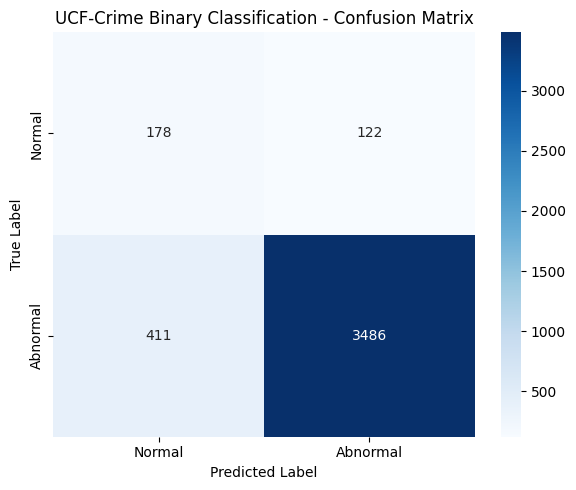

In [36]:
# ============================================
# CELL 10 — CONFUSION MATRIX
# ============================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Create confusion matrix
cm = confusion_matrix(
    all_labels,
    all_predictions
)

print("============================================")
print("CONFUSION MATRIX")
print("============================================")

print(cm)

# Plot
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Abnormal"],
    yticklabels=["Normal", "Abnormal"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("UCF-Crime Binary Classification - Confusion Matrix")

plt.tight_layout()
plt.show()

ROC CURVE
ROC-AUC: 0.8678


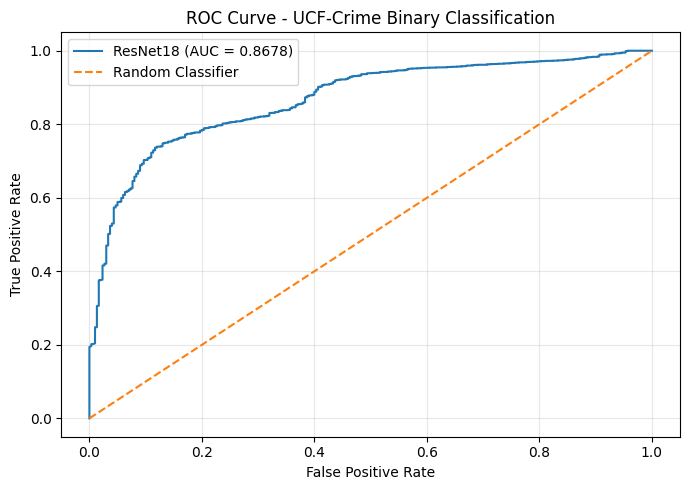

In [37]:
# ============================================
# CELL 11 — ROC CURVE
# ============================================

from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(
    all_labels,
    all_probabilities
)

print("============================================")
print("ROC CURVE")
print("============================================")

print(f"ROC-AUC: {roc_auc:.4f}")

# Plot ROC curve
plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"ResNet18 (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - UCF-Crime Binary Classification")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [38]:
# ============================================
# CELL 12 — SAVE FINAL MODEL + RESULTS
# ============================================

import os
import pandas as pd
import torch

# Create output folders
os.makedirs("/kaggle/working/models", exist_ok=True)
os.makedirs("/kaggle/working/results", exist_ok=True)

# Save model
MODEL_PATH = "/kaggle/working/models/resnet18_ucf_crime_final.pth"

torch.save(
    model.state_dict(),
    MODEL_PATH
)

# Save metrics
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

RESULTS_PATH = "/kaggle/working/results/final_results.csv"

results.to_csv(
    RESULTS_PATH,
    index=False
)

print("============================================")
print("FINAL MODEL SAVED")
print("============================================")

print("Model path:")
print(MODEL_PATH)

print("\nResults path:")
print(RESULTS_PATH)

print("\nFinal Results:")
print(results)

FINAL MODEL SAVED
Model path:
/kaggle/working/models/resnet18_ucf_crime_final.pth

Results path:
/kaggle/working/results/final_results.csv

Final Results:
      Metric     Value
0   Accuracy  0.873005
1  Precision  0.966186
2     Recall  0.894534
3   F1 Score  0.928981
4    ROC-AUC  0.867789


In [40]:
# ============================================
# CELL 13 — FIND arrest1.gif
# ============================================

import glob
import os

print("============================================")
print("FINDING arrest1.gif")
print("============================================")

# Only search the datasets directory.
# This is NOT a recursive search through UCF Crime.

possible_paths = []

possible_paths += glob.glob(
    "/kaggle/input/datasets/*/arrest1.gif"
)

possible_paths += glob.glob(
    "/kaggle/input/datasets/*/*/arrest1.gif"
)

if len(possible_paths) > 0:

    GIF_PATH = possible_paths[0]

    print("✅ arrest1.gif FOUND!")
    print()
    print("Actual path:")
    print(GIF_PATH)

    print()
    print("File exists:",
          os.path.exists(GIF_PATH))

else:

    print("❌ arrest1.gif was not found.")

    print("\nChecking dataset folders:")

    for path in glob.glob(
        "/kaggle/input/datasets/*"
    ):

        print(" -", path)

FINDING arrest1.gif
✅ arrest1.gif FOUND!

Actual path:
/kaggle/input/datasets/dhruveesalian/arrest1/arrest1.gif

File exists: True


UCF-CRIME ALL-FRAME ANALYSIS
GIF: /kaggle/input/datasets/dhruveesalian/arrest1/arrest1.gif
Device: cuda

GIF found successfully.

Video information
-------------------------------------------------------
Resolution    : 320 x 240
Total frames  : 241

Loading ResNet18 model...
Model loaded successfully.
Device: cuda

ANALYZING ALL FRAMES
Processed 32/241 frames
Processed 64/241 frames
Processed 96/241 frames
Processed 128/241 frames
Processed 160/241 frames
Processed 192/241 frames
Processed 224/241 frames
Processed 241/241 frames

FINAL VIDEO ANALYSIS
Video/GIF              : arrest1.gif
Resolution             : 320 x 240
Total frames           : 241
Frames analyzed        : 241

Normal frames          : 239
Abnormal frames        : 2

Normal percentage      : 99.17%
Abnormal percentage    : 0.83%

Average normal prob.   : 96.01%
Average abnormal prob. : 3.99%

FINAL PREDICTION       : NORMAL

Results saved to: /kaggle/working/results/arrest1_all_frame_predictions.csv

Creating Normal/

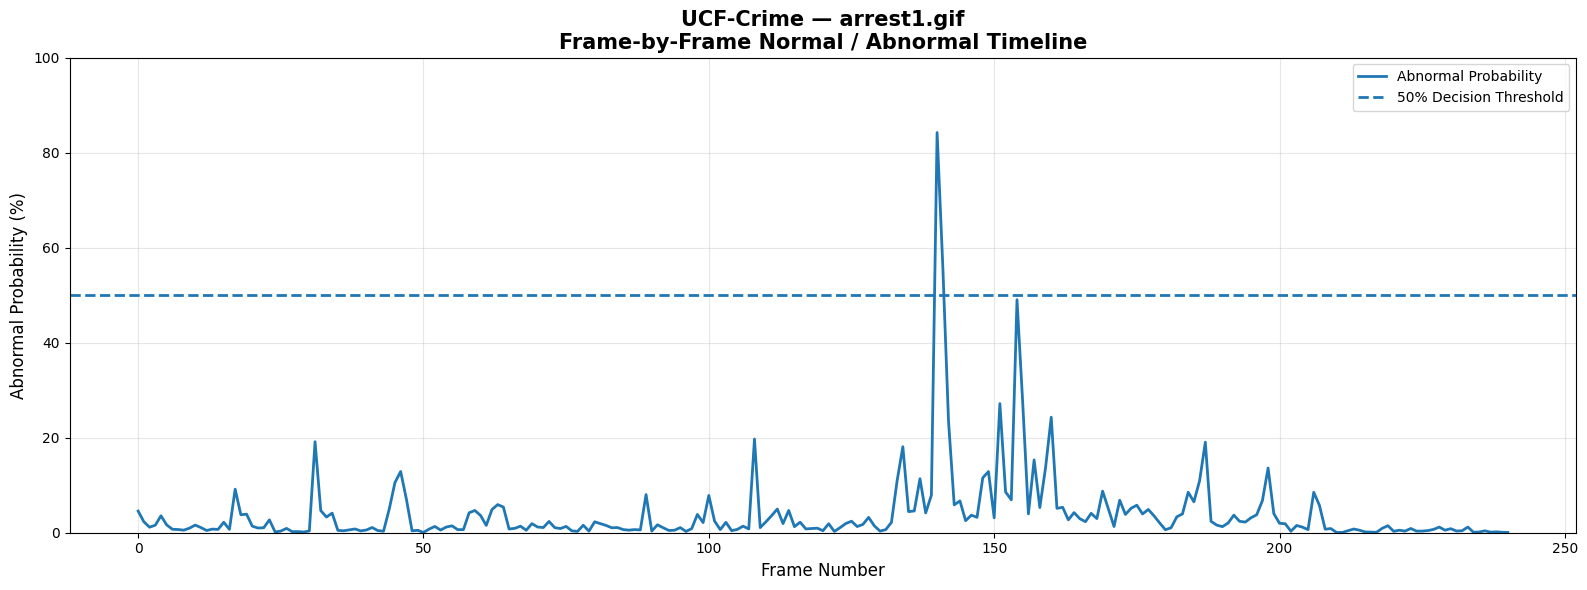


PREDICTION DISTRIBUTION


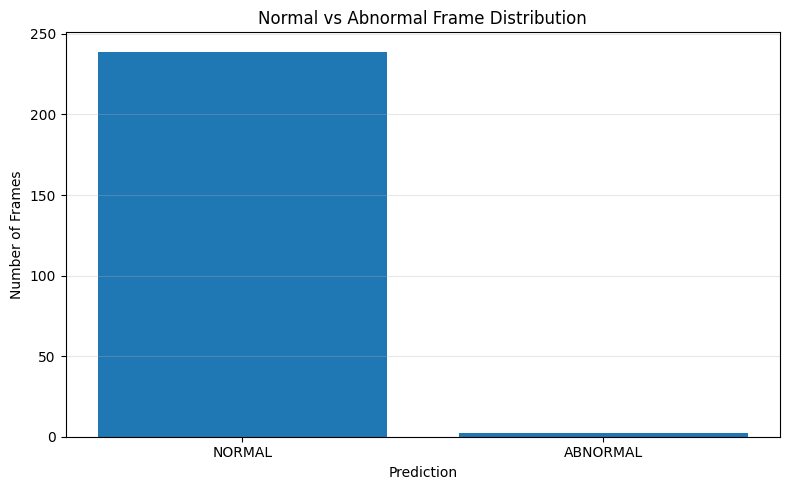


TOP 10 MOST ABNORMAL FRAMES
 Frame Prediction  Confidence (%)  Abnormal Probability (%)
   140   ABNORMAL           84.21                     84.21
   141   ABNORMAL           56.06                     56.06
   154     NORMAL           50.97                     49.03
   155     NORMAL           72.60                     27.40
   151     NORMAL           72.83                     27.17
   160     NORMAL           75.69                     24.31
   142     NORMAL           76.50                     23.50
   108     NORMAL           80.29                     19.71
    31     NORMAL           80.84                     19.16
   187     NORMAL           80.95                     19.05

ANALYSIS COMPLETE
CSV:
/kaggle/working/results/arrest1_all_frame_predictions.csv

Timeline graph:
/kaggle/working/results/arrest1_normal_abnormal_timeline.png

Prediction distribution:
/kaggle/working/results/arrest1_prediction_distribution.png


In [41]:
# ============================================================
# CELL 14 — ANALYZE ALL FRAMES + TIMELINE GRAPH
# ============================================================

import os
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from PIL import Image
from torchvision import models, transforms

# ============================================================
# 1. SETTINGS
# ============================================================

# Your GIF
GIF_PATH = "/kaggle/input/datasets/dhruveesalian/arrest1/arrest1.gif"

# Your saved ResNet18 model
MODEL_PATH = "/kaggle/working/models/resnet18_ucf_crime_final.pth"

# Output folder
RESULTS_DIR = "/kaggle/working/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 55)
print("UCF-CRIME ALL-FRAME ANALYSIS")
print("=" * 55)

print("GIF:", GIF_PATH)
print("Device:", DEVICE)


# ============================================================
# 2. CHECK GIF
# ============================================================

if not os.path.exists(GIF_PATH):
    raise FileNotFoundError(
        f"GIF not found:\n{GIF_PATH}\n\n"
        "Check that arrest1 dataset is added to Kaggle Input."
    )

print("\nGIF found successfully.")


# ============================================================
# 3. LOAD GIF
# ============================================================

gif = Image.open(GIF_PATH)

total_frames = gif.n_frames
width, height = gif.size

print("\nVideo information")
print("-" * 55)
print("Resolution    :", width, "x", height)
print("Total frames  :", total_frames)


# ============================================================
# 4. CREATE SAME RESNET18 ARCHITECTURE
# ============================================================

print("\nLoading ResNet18 model...")

model = models.resnet18(weights=None)

num_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(num_features, 1)
)

# Load trained weights
checkpoint = torch.load(
    MODEL_PATH,
    map_location=DEVICE
)

# Handle either state_dict or saved model dictionary
if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
else:
    model.load_state_dict(checkpoint)

model = model.to(DEVICE)
model.eval()

print("Model loaded successfully.")
print("Device:", DEVICE)


# ============================================================
# 5. IMAGE PREPROCESSING
#    SAME NORMALIZATION USED DURING TRAINING
# ============================================================

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# ============================================================
# 6. ANALYZE ALL FRAMES
# ============================================================

print("\n" + "=" * 55)
print("ANALYZING ALL FRAMES")
print("=" * 55)

frame_numbers = []
predictions = []
confidences = []
abnormal_probabilities = []
normal_probabilities = []

# Batch processing makes GPU inference faster
BATCH_SIZE = 32

batch_images = []
batch_frame_numbers = []


def process_batch(images, frame_nums):

    if len(images) == 0:
        return

    batch = torch.stack(images).to(DEVICE)

    with torch.no_grad():

        outputs = model(batch)

        abnormal_probs = torch.sigmoid(
            outputs.view(-1)
        )

    for frame_no, abnormal_prob in zip(
        frame_nums,
        abnormal_probs
    ):

        abnormal_prob = float(abnormal_prob.item())

        normal_prob = 1.0 - abnormal_prob

        if abnormal_prob >= 0.5:

            prediction = "ABNORMAL"
            confidence = abnormal_prob

        else:

            prediction = "NORMAL"
            confidence = normal_prob

        frame_numbers.append(frame_no)
        predictions.append(prediction)
        confidences.append(confidence * 100)
        abnormal_probabilities.append(abnormal_prob * 100)
        normal_probabilities.append(normal_prob * 100)


# ============================================================
# READ EVERY FRAME
# ============================================================

for frame_no in range(total_frames):

    gif.seek(frame_no)

    frame = gif.convert("RGB")

    image_tensor = transform(frame)

    batch_images.append(image_tensor)
    batch_frame_numbers.append(frame_no)

    # Process batch
    if len(batch_images) == BATCH_SIZE:

        process_batch(
            batch_images,
            batch_frame_numbers
        )

        batch_images = []
        batch_frame_numbers = []

        print(
            f"Processed {frame_no + 1}/{total_frames} frames"
        )


# Process remaining frames
if len(batch_images) > 0:

    process_batch(
        batch_images,
        batch_frame_numbers
    )

    print(
        f"Processed {total_frames}/{total_frames} frames"
    )


# ============================================================
# 7. CREATE RESULTS DATAFRAME
# ============================================================

results_df = pd.DataFrame({

    "Frame": frame_numbers,

    "Prediction": predictions,

    "Confidence (%)": np.round(
        confidences,
        2
    ),

    "Normal Probability (%)": np.round(
        normal_probabilities,
        2
    ),

    "Abnormal Probability (%)": np.round(
        abnormal_probabilities,
        2
    )
})


# ============================================================
# 8. SAVE FRAME RESULTS
# ============================================================

csv_path = os.path.join(
    RESULTS_DIR,
    "arrest1_all_frame_predictions.csv"
)

results_df.to_csv(
    csv_path,
    index=False
)


# ============================================================
# 9. CALCULATE FINAL RESULTS
# ============================================================

normal_count = (
    results_df["Prediction"] == "NORMAL"
).sum()

abnormal_count = (
    results_df["Prediction"] == "ABNORMAL"
).sum()

normal_percentage = (
    normal_count / total_frames
) * 100

abnormal_percentage = (
    abnormal_count / total_frames
) * 100

average_normal_probability = (
    results_df["Normal Probability (%)"].mean()
)

average_abnormal_probability = (
    results_df["Abnormal Probability (%)"].mean()
)

if abnormal_count > normal_count:

    final_prediction = "ABNORMAL"

else:

    final_prediction = "NORMAL"


# ============================================================
# 10. PRINT FINAL SUMMARY
# ============================================================

print("\n" + "=" * 55)
print("FINAL VIDEO ANALYSIS")
print("=" * 55)

print("Video/GIF              :", "arrest1.gif")
print("Resolution             :", f"{width} x {height}")
print("Total frames           :", total_frames)
print("Frames analyzed        :", len(results_df))

print()

print("Normal frames          :", normal_count)
print("Abnormal frames        :", abnormal_count)

print()

print(
    f"Normal percentage      : {normal_percentage:.2f}%"
)

print(
    f"Abnormal percentage    : {abnormal_percentage:.2f}%"
)

print()

print(
    f"Average normal prob.   : "
    f"{average_normal_probability:.2f}%"
)

print(
    f"Average abnormal prob. : "
    f"{average_abnormal_probability:.2f}%"
)

print()

print(
    "FINAL PREDICTION       :",
    final_prediction
)

print()

print(
    "Results saved to:",
    csv_path
)


# ============================================================
# 11. TIMELINE GRAPH
# ============================================================

print("\nCreating Normal/Abnormal timeline...")


plt.figure(figsize=(16, 6))

# Abnormal probability line
plt.plot(
    results_df["Frame"],
    results_df["Abnormal Probability (%)"],
    linewidth=2,
    label="Abnormal Probability"
)

# 50% decision threshold
plt.axhline(
    y=50,
    linestyle="--",
    linewidth=2,
    label="50% Decision Threshold"
)

plt.xlabel(
    "Frame Number",
    fontsize=12
)

plt.ylabel(
    "Abnormal Probability (%)",
    fontsize=12
)

plt.title(
    "UCF-Crime — arrest1.gif\n"
    "Frame-by-Frame Normal / Abnormal Timeline",
    fontsize=15,
    fontweight="bold"
)

plt.ylim(0, 100)

plt.grid(
    True,
    alpha=0.3
)

plt.legend()

plt.tight_layout()


# Save graph
timeline_path = os.path.join(
    RESULTS_DIR,
    "arrest1_normal_abnormal_timeline.png"
)

plt.savefig(
    timeline_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 12. DISPLAY PREDICTION DISTRIBUTION
# ============================================================

print("\n" + "=" * 55)
print("PREDICTION DISTRIBUTION")
print("=" * 55)

plt.figure(figsize=(8, 5))

plt.bar(
    ["NORMAL", "ABNORMAL"],
    [normal_count, abnormal_count]
)

plt.xlabel("Prediction")
plt.ylabel("Number of Frames")

plt.title(
    "Normal vs Abnormal Frame Distribution"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

distribution_path = os.path.join(
    RESULTS_DIR,
    "arrest1_prediction_distribution.png"
)

plt.savefig(
    distribution_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 13. SHOW MOST ABNORMAL FRAMES
# ============================================================

print("\n" + "=" * 55)
print("TOP 10 MOST ABNORMAL FRAMES")
print("=" * 55)

top_abnormal = results_df.sort_values(
    "Abnormal Probability (%)",
    ascending=False
).head(10)

print(
    top_abnormal[
        [
            "Frame",
            "Prediction",
            "Confidence (%)",
            "Abnormal Probability (%)"
        ]
    ].to_string(index=False)
)


# ============================================================
# DONE
# ============================================================

print("\n" + "=" * 55)
print("ANALYSIS COMPLETE")
print("=" * 55)

print("CSV:")
print(csv_path)

print("\nTimeline graph:")
print(timeline_path)

print("\nPrediction distribution:")
print(distribution_path)

In [42]:
# ============================================
# CELL 15 — VERIFY SAVED PROJECT FILES
# ============================================

import os

files_to_check = [
    "/kaggle/working/models/resnet18_ucf_crime_final.pth",
    "/kaggle/working/results/final_results.csv",
    "/kaggle/working/results/arrest1_all_frame_predictions.csv",
    "/kaggle/working/results/arrest1_normal_abnormal_timeline.png",
    "/kaggle/working/results/arrest1_prediction_distribution.png"
]

print("============================================")
print("SAVED PROJECT FILES")
print("============================================")

for file_path in files_to_check:

    if os.path.exists(file_path):

        size_mb = os.path.getsize(file_path) / (1024 * 1024)

        print("✅", os.path.basename(file_path))
        print("   Size:", f"{size_mb:.2f} MB")

    else:
        print("❌", os.path.basename(file_path))

print("\nVerification completed.")

SAVED PROJECT FILES
✅ resnet18_ucf_crime_final.pth
   Size: 42.71 MB
✅ final_results.csv
   Size: 0.00 MB
✅ arrest1_all_frame_predictions.csv
   Size: 0.01 MB
✅ arrest1_normal_abnormal_timeline.png
   Size: 0.16 MB
✅ arrest1_prediction_distribution.png
   Size: 0.04 MB

Verification completed.


In [43]:
# ============================================
# CELL 16 — FINAL PROJECT SUMMARY
# ============================================

print("================================================")
print("UCF-CRIME CROWD INCIDENT DETECTION")
print("FINAL PROJECT SUMMARY")
print("================================================")

print("\nMODEL")
print("-----------------------------------------------")
print("Architecture        : ResNet18")
print("Learning approach   : Transfer Learning")
print("Fine-tuned layers   : layer4 + fc")
print("Input size          : 224 x 224")
print("Classes             : Normal / Abnormal")
print("Device              : Tesla T4 GPU")

print("\nDATASET")
print("-----------------------------------------------")
print("Training images     : 14,000")
print("  Normal            : 1,000")
print("  Abnormal          : 13,000")
print("Testing images      : 4,197")
print("  Normal            : 300")
print("  Abnormal          : 3,897")

print("\nFINAL TEST PERFORMANCE")
print("-----------------------------------------------")
print(f"Accuracy            : {accuracy * 100:.2f}%")
print(f"Precision           : {precision * 100:.2f}%")
print(f"Recall              : {recall * 100:.2f}%")
print(f"F1 Score            : {f1 * 100:.2f}%")
print(f"ROC-AUC             : {roc_auc:.4f}")

print("\nARREST1.GIF ANALYSIS")
print("-----------------------------------------------")
print("Total frames        : 241")
print("Normal frames       : 239")
print("Abnormal frames     : 2")
print("Normal percentage   : 99.17%")
print("Abnormal percentage : 0.83%")
print("Final prediction    : NORMAL")

print("\n================================================")
print("PROJECT PIPELINE COMPLETED SUCCESSFULLY")
print("================================================")

UCF-CRIME CROWD INCIDENT DETECTION
FINAL PROJECT SUMMARY

MODEL
-----------------------------------------------
Architecture        : ResNet18
Learning approach   : Transfer Learning
Fine-tuned layers   : layer4 + fc
Input size          : 224 x 224
Classes             : Normal / Abnormal
Device              : Tesla T4 GPU

DATASET
-----------------------------------------------
Training images     : 14,000
  Normal            : 1,000
  Abnormal          : 13,000
Testing images      : 4,197
  Normal            : 300
  Abnormal          : 3,897

FINAL TEST PERFORMANCE
-----------------------------------------------
Accuracy            : 87.30%
Precision           : 96.62%
Recall              : 89.45%
F1 Score            : 92.90%
ROC-AUC             : 0.8678

ARREST1.GIF ANALYSIS
-----------------------------------------------
Total frames        : 241
Normal frames       : 239
Abnormal frames     : 2
Normal percentage   : 99.17%
Abnormal percentage : 0.83%
Final prediction    : NORMAL

P

In [46]:
# ============================================================
# CELL 17 — UPLOAD + PLAY GIF + FRAME-BY-FRAME ANALYSIS
# ============================================================

import os
import cv2
import torch
import torch.nn as nn
import numpy as np

from PIL import Image
from io import BytesIO
from IPython.display import display, clear_output, HTML

from torchvision import models, transforms

import ipywidgets as widgets


# ============================================================
# 1. DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)


# ============================================================
# 2. LOAD TRAINED MODEL
# ============================================================

MODEL_PATH = "/kaggle/working/models/resnet18_ucf_crime_final.pth"

model = models.resnet18(weights=None)

num_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(num_features, 1)
)

checkpoint = torch.load(
    MODEL_PATH,
    map_location=device
)

if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    checkpoint = checkpoint["model_state_dict"]

model.load_state_dict(checkpoint)

model = model.to(device)

model.eval()

print("Model loaded successfully!")


# ============================================================
# 3. IMAGE TRANSFORM
# ============================================================

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# ============================================================
# 4. UPLOAD WIDGET
# ============================================================

upload = widgets.FileUpload(
    accept=".jpg,.jpeg,.png,.bmp,.gif,.mp4,.avi,.mov,.mkv",
    multiple=False,
    description="Choose File"
)

analyze_button = widgets.Button(
    description="Analyze",
    button_style="success"
)

output = widgets.Output()


# ============================================================
# 5. GET FILE
# ============================================================

def get_uploaded_file():

    if len(upload.value) == 0:
        return None, None

    if isinstance(upload.value, tuple):

        uploaded_file = upload.value[0]

        file_name = uploaded_file["name"]
        file_data = uploaded_file["content"]

    else:

        file_name = list(upload.value.keys())[0]

        file_data = upload.value[file_name]["content"]

    return file_name, file_data


# ============================================================
# 6. PREDICT ONE FRAME
# ============================================================

def predict_frame(image):

    image = image.convert("RGB")

    tensor = transform(image)

    tensor = tensor.unsqueeze(0)

    tensor = tensor.to(device)

    with torch.no_grad():

        output_value = model(tensor)

        abnormal_probability = torch.sigmoid(
            output_value
        ).item()

    normal_probability = 1 - abnormal_probability

    if abnormal_probability >= 0.5:

        prediction = "ABNORMAL"

    else:

        prediction = "NORMAL"

    return (
        prediction,
        normal_probability,
        abnormal_probability
    )


# ============================================================
# 7. ANALYZE GIF
# ============================================================

def analyze_gif(file_data):

    gif = Image.open(
        BytesIO(file_data)
    )

    frame_predictions = []

    frame_number = 0

    while True:

        try:

            gif.seek(frame_number)

        except EOFError:

            break

        frame = gif.convert("RGB")

        prediction, normal_prob, abnormal_prob = \
            predict_frame(frame)

        frame_predictions.append({
            "frame": frame_number + 1,
            "prediction": prediction,
            "normal_probability": normal_prob,
            "abnormal_probability": abnormal_prob
        })

        frame_number += 1

    return gif, frame_predictions


# ============================================================
# 8. SHOW GIF PLAYING
# ============================================================

def show_gif(file_data):

    # Save GIF to Kaggle working directory
    gif_path = "/kaggle/working/uploaded.gif"

    with open(gif_path, "wb") as f:

        f.write(file_data)

    # Read GIF bytes
    import base64

    encoded = base64.b64encode(
        file_data
    ).decode("utf-8")

    # HTML GIF player
    html = f"""
    <div style="
        text-align:center;
        margin:20px;
    ">

        <h3>Uploaded GIF</h3>

        <img
            src="data:image/gif;base64,{encoded}"
            style="
                max-width:600px;
                max-height:400px;
                border:3px solid #333;
                border-radius:10px;
            "
        >

    </div>
    """

    display(
        HTML(html)
    )


# ============================================================
# 9. DISPLAY RESULTS
# ============================================================

def show_results(frame_predictions):

    total_frames = len(frame_predictions)

    normal_frames = sum(
        1
        for x in frame_predictions
        if x["prediction"] == "NORMAL"
    )

    abnormal_frames = sum(
        1
        for x in frame_predictions
        if x["prediction"] == "ABNORMAL"
    )

    normal_percentage = (
        normal_frames / total_frames
    ) * 100

    abnormal_percentage = (
        abnormal_frames / total_frames
    ) * 100

    avg_normal = np.mean([
        x["normal_probability"]
        for x in frame_predictions
    ])

    avg_abnormal = np.mean([
        x["abnormal_probability"]
        for x in frame_predictions
    ])

    if abnormal_percentage >= 50:

        final_prediction = "ABNORMAL"
        confidence = abnormal_percentage

    else:

        final_prediction = "NORMAL"
        confidence = normal_percentage

    print()
    print("=" * 60)
    print("             UCF-CRIME DETECTION")
    print("=" * 60)

    print(
        f"\nTotal Frames Analyzed : {total_frames}"
    )

    print(
        f"Normal Frames         : {normal_frames}"
    )

    print(
        f"Abnormal Frames       : {abnormal_frames}"
    )

    print()

    print(
        f"Normal Percentage     : "
        f"{normal_percentage:.2f}%"
    )

    print(
        f"Abnormal Percentage   : "
        f"{abnormal_percentage:.2f}%"
    )

    print()

    print(
        f"Average Normal Prob.  : "
        f"{avg_normal * 100:.2f}%"
    )

    print(
        f"Average Abnormal Prob.: "
        f"{avg_abnormal * 100:.2f}%"
    )

    print()
    print("-" * 60)

    print(
        f"FINAL PREDICTION      : "
        f"{final_prediction}"
    )

    print(
        f"CONFIDENCE            : "
        f"{confidence:.2f}%"
    )

    print("=" * 60)


# ============================================================
# 10. ANALYZE BUTTON
# ============================================================

def analyze_file(button):

    with output:

        clear_output()

        file_name, file_data = get_uploaded_file()

        if file_name is None:

            print(
                "Please upload an image, GIF, or video."
            )

            return

        print(
            "Uploaded:",
            file_name
        )

        extension = os.path.splitext(
            file_name
        )[1].lower()


        # ====================================================
        # GIF
        # ====================================================

        if extension == ".gif":

            print("\nPlaying GIF...")

            # SHOW / PLAY GIF
            show_gif(file_data)

            print(
                "\nAnalyzing every frame..."
            )

            gif, frame_predictions = \
                analyze_gif(file_data)

            print(
                f"Finished analyzing "
                f"{len(frame_predictions)} frames."
            )

            show_results(
                frame_predictions
            )


        # ====================================================
        # IMAGE
        # ====================================================

        elif extension in [
            ".jpg",
            ".jpeg",
            ".png",
            ".bmp"
        ]:

            image = Image.open(
                BytesIO(file_data)
            ).convert("RGB")

            display(image)

            prediction, normal_prob, abnormal_prob = \
                predict_frame(image)

            print()
            print("=" * 60)
            print("IMAGE RESULT")
            print("=" * 60)

            print(
                f"\nPrediction: {prediction}"
            )

            print(
                f"Normal Probability: "
                f"{normal_prob * 100:.2f}%"
            )

            print(
                f"Abnormal Probability: "
                f"{abnormal_prob * 100:.2f}%"
            )

            print(
                f"\nConfidence: "
                f"{max(normal_prob, abnormal_prob) * 100:.2f}%"
            )

            print("=" * 60)


        # ====================================================
        # VIDEO
        # ====================================================

        elif extension in [
            ".mp4",
            ".avi",
            ".mov",
            ".mkv"
        ]:

            video_path = (
                "/kaggle/working/uploaded_video"
                + extension
            )

            with open(video_path, "wb") as f:

                f.write(file_data)

            cap = cv2.VideoCapture(
                video_path
            )

            total_frames = int(
                cap.get(cv2.CAP_PROP_FRAME_COUNT)
            )

            print(
                f"\nTotal Frames: {total_frames}"
            )

            frame_predictions = []

            frame_number = 0

            while True:

                success, frame = cap.read()

                if not success:
                    break

                frame_rgb = cv2.cvtColor(
                    frame,
                    cv2.COLOR_BGR2RGB
                )

                image = Image.fromarray(
                    frame_rgb
                )

                prediction, normal_prob, abnormal_prob = \
                    predict_frame(image)

                frame_predictions.append({
                    "frame": frame_number + 1,
                    "prediction": prediction,
                    "normal_probability": normal_prob,
                    "abnormal_probability": abnormal_prob
                })

                frame_number += 1

                if frame_number % 50 == 0:

                    print(
                        f"Processed "
                        f"{frame_number}/{total_frames}"
                    )

            cap.release()

            print("\nAnalysis complete!")

            show_results(
                frame_predictions
            )


        else:

            print(
                "Unsupported file format."
            )


# ============================================================
# 11. CONNECT BUTTON
# ============================================================

analyze_button.on_click(
    analyze_file
)


# ============================================================
# 12. DISPLAY INTERFACE
# ============================================================

print()
print("==============================================")
print("      UCF-CRIME VIDEO DETECTION SYSTEM")
print("==============================================")
print()
print("Upload an image, GIF, or video:")
print()

display(upload)

display(analyze_button)

display(output)

Device: cuda
Model loaded successfully!

      UCF-CRIME VIDEO DETECTION SYSTEM

Upload an image, GIF, or video:



FileUpload(value=(), accept='.jpg,.jpeg,.png,.bmp,.gif,.mp4,.avi,.mov,.mkv', description='Choose File')

Button(button_style='success', description='Analyze', style=ButtonStyle())

Output()